# Outlier Detection and Treatment

## Objective

In this notebook, we will:

- Preserve the original Heart Failure dataset
- Select continuous numerical features
- Detect outliers using Z-Score
- Detect outliers using IQR
- Visualize outliers using a Box Plot
- Visualize unusual relationships using a Scatter Plot
- Detect outliers using Standard Deviation bounds
- Remove outliers
- Apply Winsorization
- Apply Capping
- Apply Log Transformation
- Compare the results
- Discuss domain-specific handling


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from scipy.stats.mstats import winsorize

In [4]:
df = pd.read_csv(
    "../heart_failure_clinical_records_dataset-selected-columns.csv"
)

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
0,75.0,0,582,0,20,1,265000.00,1.9,130,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0


In [5]:
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (299, 10)
Missing Values: 0
Duplicate Rows: 0


In [6]:
numerical_features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

df[numerical_features].describe()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
count,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000
mean,60.833893,581.839465,38.083612,263358.029264,1.39388,136.625418
std,11.894809,970.287881,11.834841,97804.236869,1.03451,4.412477
min,40.000000,23.000000,14.000000,25100.000000,0.50000,113.000000
25%,51.000000,116.500000,30.000000,212500.000000,0.90000,134.000000
50%,60.000000,250.000000,38.000000,262000.000000,1.10000,137.000000
75%,70.000000,582.000000,45.000000,303500.000000,1.40000,140.000000
max,95.000000,7861.000000,80.000000,850000.000000,9.40000,148.000000


# Z-Score Detection

Z-Score measures how many standard deviations an observation is away from the mean.

A common threshold is:

```text
|Z-Score| > 3
```

In [7]:
z_score_feature = "age"

df_zscore = df.copy()

df_zscore["age_zscore"] = zscore(
    df_zscore[z_score_feature]
)

df_zscore[
    [z_score_feature, "age_zscore"]
].head()

,age,age_zscore
0,75.0,1.192945
1,55.0,-0.491279
2,65.0,0.350833
3,50.0,-0.912335
4,65.0,0.350833


In [8]:
zscore_outliers = df_zscore[
    df_zscore["age_zscore"].abs() > 3
]

print("Z-Score Outlier Count:", len(zscore_outliers))

zscore_outliers[
    [z_score_feature, "age_zscore"]
]

Z-Score Outlier Count: 0


,age,age_zscore


# IQR Detection

The IQR Method uses the first and third quartiles and is suitable for skewed data.

In [9]:
iqr_feature = "serum_creatinine"

q1 = df[iqr_feature].quantile(0.25)
q3 = df[iqr_feature].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 0.9
Q3: 1.4
IQR: 0.4999999999999999
Lower Bound: 0.15000000000000024
Upper Bound: 2.1499999999999995


In [10]:
iqr_outliers = df[
    (df[iqr_feature] < lower_bound)
    | (df[iqr_feature] > upper_bound)
]

print("IQR Outlier Count:", len(iqr_outliers))

iqr_outliers[
    [iqr_feature]
].sort_values(
    by=iqr_feature,
    ascending=False
)

IQR Outlier Count: 29


,serum_creatinine
9,9.4
217,9.0
52,6.8
131,6.1
28,5.8
228,5.0
48,4.4
10,4.0
282,3.8
124,3.7


# Box Plot

The Box Plot visually highlights observations outside the whisker boundaries.

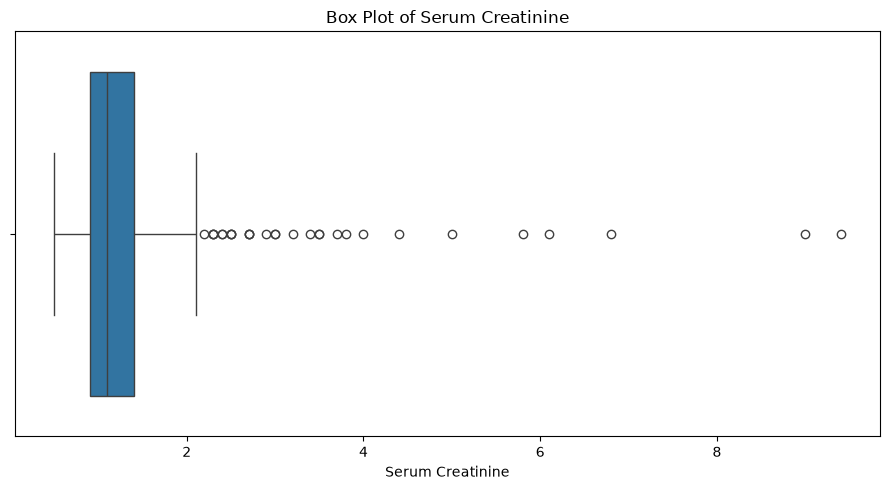

In [11]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    x=df[iqr_feature]
)

plt.title("Box Plot of Serum Creatinine")
plt.xlabel("Serum Creatinine")

plt.tight_layout()
plt.show()

# Scatter Plot

The Scatter Plot shows unusual observations within the relationship between Age and Serum Creatinine.

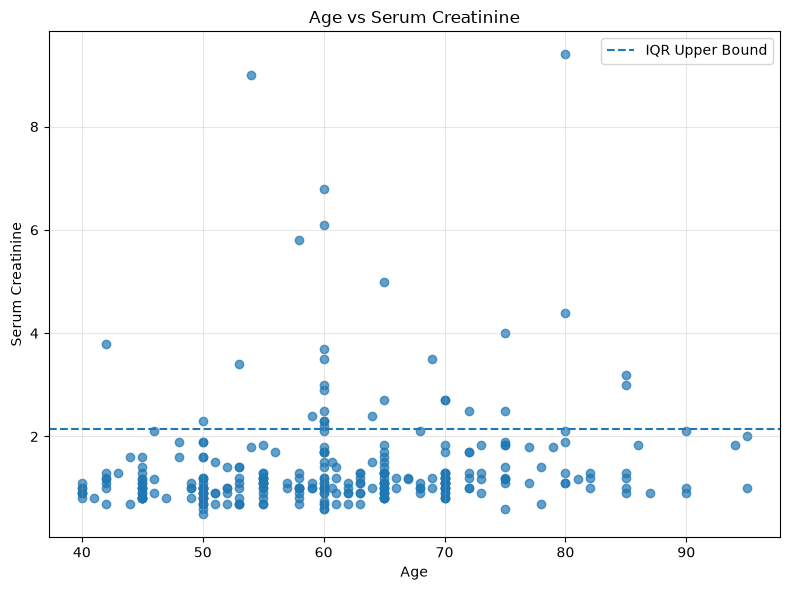

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["age"],
    df["serum_creatinine"],
    alpha=0.7
)

plt.axhline(
    upper_bound,
    linestyle="--",
    label="IQR Upper Bound"
)

plt.xlabel("Age")
plt.ylabel("Serum Creatinine")
plt.title("Age vs Serum Creatinine")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Standard Deviation Method

This method identifies observations outside three standard deviations from the mean.

In [13]:
std_feature = "age"

mean_value = df[std_feature].mean()
std_value = df[std_feature].std()

std_lower_bound = mean_value - (3 * std_value)
std_upper_bound = mean_value + (3 * std_value)

print("Mean:", mean_value)
print("Standard Deviation:", std_value)
print("Lower Bound:", std_lower_bound)
print("Upper Bound:", std_upper_bound)

Mean: 60.83389297658862
Standard Deviation: 11.89480907404447
Lower Bound: 25.149465754455214
Upper Bound: 96.51832019872202


In [14]:
std_outliers = df[
    (df[std_feature] < std_lower_bound)
    | (df[std_feature] > std_upper_bound)
]

print(
    "Standard Deviation Outlier Count:",
    len(std_outliers)
)

std_outliers[[std_feature]]

Standard Deviation Outlier Count: 0


,age


# Complete Outlier Removal

Rows outside the IQR boundaries will be removed from a separate DataFrame copy.

In [15]:
df_removed = df.copy()

rows_before = len(df_removed)

df_removed = df_removed[
    (df_removed[iqr_feature] >= lower_bound)
    & (df_removed[iqr_feature] <= upper_bound)
].copy()

rows_after = len(df_removed)

print("Rows Before:", rows_before)
print("Rows After:", rows_after)
print("Rows Removed:", rows_before - rows_after)

Rows Before: 299
Rows After: 270
Rows Removed: 29


In [16]:
removal_percentage = (
    (rows_before - rows_after)
    / rows_before
) * 100

print(
    f"Data Loss After Removal: "
    f"{removal_percentage:.2f}%"
)

Data Loss After Removal: 9.70%


# Winsorization

Winsorization replaces the lowest and highest selected percentages with boundary values.

The original rows remain available.

In [17]:
df_winsorized = df.copy()

df_winsorized[
    "serum_creatinine_winsorized"
] = np.asarray(
    winsorize(
        df_winsorized["serum_creatinine"],
        limits=[0.05, 0.05]
    )
)

df_winsorized[
    [
        "serum_creatinine",
        "serum_creatinine_winsorized"
    ]
].sort_values(
    by="serum_creatinine",
    ascending=False
).head(10)

,serum_creatinine,serum_creatinine_winsorized
9,9.4,3.0
217,9.0,3.0
52,6.8,3.0
131,6.1,3.0
28,5.8,3.0
228,5.0,3.0
48,4.4,3.0
10,4.0,3.0
282,3.8,3.0
124,3.7,3.0


# Capping

IQR Capping replaces values below the lower boundary and above the upper boundary with their nearest boundary.

In [18]:
df_capped = df.copy()

df_capped[
    "serum_creatinine_capped"
] = df_capped[
    "serum_creatinine"
].clip(
    lower=lower_bound,
    upper=upper_bound
)

df_capped[
    [
        "serum_creatinine",
        "serum_creatinine_capped"
    ]
].sort_values(
    by="serum_creatinine",
    ascending=False
).head(10)

,serum_creatinine,serum_creatinine_capped
9,9.4,2.15
217,9.0,2.15
52,6.8,2.15
131,6.1,2.15
28,5.8,2.15
228,5.0,2.15
48,4.4,2.15
10,4.0,2.15
282,3.8,2.15
124,3.7,2.15


# Log Transformation

Log Transformation reduces right skewness and compresses large positive values.

In [19]:
df_log = df.copy()

df_log[
    "serum_creatinine_log"
] = np.log1p(
    df_log["serum_creatinine"]
)

df_log[
    [
        "serum_creatinine",
        "serum_creatinine_log"
    ]
].head()

,serum_creatinine,serum_creatinine_log
0,1.9,1.064711
1,1.1,0.741937
2,1.3,0.832909
3,1.9,1.064711
4,2.7,1.308333


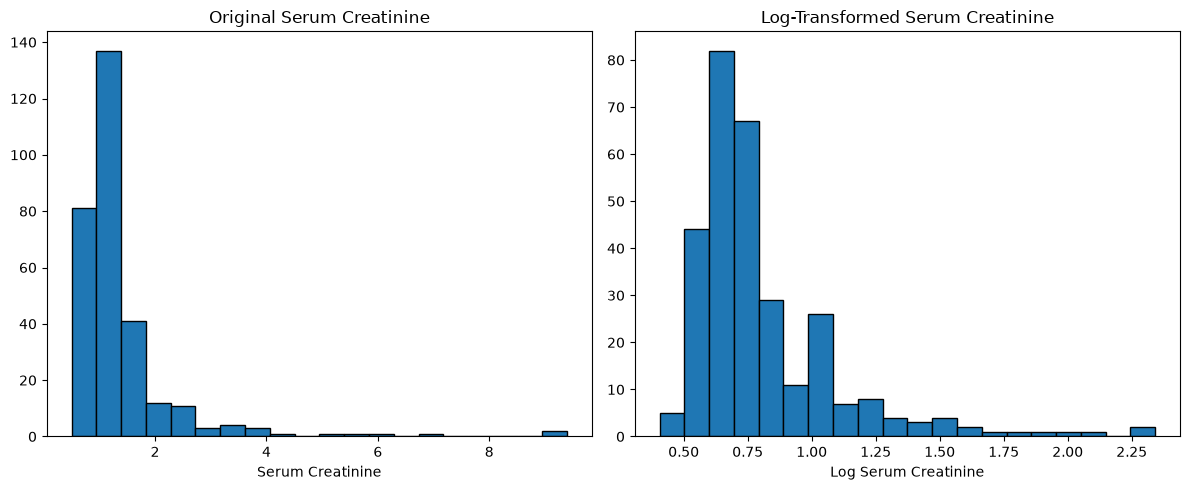

In [20]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].hist(
    df_log["serum_creatinine"],
    bins=20,
    edgecolor="black"
)

axes[0].set_title(
    "Original Serum Creatinine"
)

axes[0].set_xlabel(
    "Serum Creatinine"
)

axes[1].hist(
    df_log["serum_creatinine_log"],
    bins=20,
    edgecolor="black"
)

axes[1].set_title(
    "Log-Transformed Serum Creatinine"
)

axes[1].set_xlabel(
    "Log Serum Creatinine"
)

plt.tight_layout()
plt.show()

# Domain-Specific Review

An extreme medical value should not be removed only because it is statistically unusual.

The observation should be checked for:

- Biological possibility
- Measurement units
- Data-entry errors
- Clinical importance
- Rare but valid patient conditions

In [21]:
domain_review = df[
    df["serum_creatinine"] > upper_bound
].sort_values(
    by="serum_creatinine",
    ascending=False
)

domain_review[
    [
        "age",
        "diabetes",
        "ejection_fraction",
        "serum_creatinine",
        "serum_sodium"
    ]
].head(10)

,age,diabetes,ejection_fraction,serum_creatinine,serum_sodium
9,80.0,0,35,9.4,133
217,54.0,0,70,9.0,137
52,60.0,1,62,6.8,146
131,60.0,1,45,6.1,131
28,58.0,0,38,5.8,134
228,65.0,0,25,5.0,130
48,80.0,0,20,4.4,133
10,75.0,0,38,4.0,131
282,42.0,0,30,3.8,128
124,60.0,0,40,3.7,134


# Compare Treatment Results

The comparison shows how each treatment changes the same extreme observations.

In [22]:
comparison_indexes = (
    df["serum_creatinine"]
    .sort_values(ascending=False)
    .head(10)
    .index
)

outlier_comparison = pd.DataFrame({
    "Original": (
        df.loc[
            comparison_indexes,
            "serum_creatinine"
        ]
    ),
    "Winsorized": (
        df_winsorized.loc[
            comparison_indexes,
            "serum_creatinine_winsorized"
        ]
    ),
    "Capped": (
        df_capped.loc[
            comparison_indexes,
            "serum_creatinine_capped"
        ]
    ),
    "Log Transformed": (
        df_log.loc[
            comparison_indexes,
            "serum_creatinine_log"
        ]
    )
})

outlier_comparison

,Original,Winsorized,Capped,Log Transformed
9,9.4,3.0,2.15,2.341806
217,9.0,3.0,2.15,2.302585
52,6.8,3.0,2.15,2.054124
131,6.1,3.0,2.15,1.960095
28,5.8,3.0,2.15,1.916923
228,5.0,3.0,2.15,1.791759
48,4.4,3.0,2.15,1.686399
10,4.0,3.0,2.15,1.609438
282,3.8,3.0,2.15,1.568616
124,3.7,3.0,2.15,1.547563


In [23]:
treatment_summary = pd.DataFrame({
    "Method": [
        "Original",
        "Removal",
        "Winsorization",
        "Capping",
        "Log Transformation"
    ],
    "Rows": [
        len(df),
        len(df_removed),
        len(df_winsorized),
        len(df_capped),
        len(df_log)
    ],
    "Maximum Value": [
        df["serum_creatinine"].max(),
        df_removed["serum_creatinine"].max(),
        df_winsorized[
            "serum_creatinine_winsorized"
        ].max(),
        df_capped[
            "serum_creatinine_capped"
        ].max(),
        df_log[
            "serum_creatinine_log"
        ].max()
    ]
})

treatment_summary


,Method,Rows,Maximum Value
0,Original,299,9.400000
1,Removal,270,2.100000
2,Winsorization,299,3.000000
3,Capping,299,2.150000
4,Log Transformation,299,2.341806


In [24]:
print("Original Shape:", df.shape)

print(
    "Original Maximum Serum Creatinine:",
    df["serum_creatinine"].max()
)

print(
    "Original Missing Values:",
    df.isnull().sum().sum()
)

Original Shape: (299, 10)
Original Maximum Serum Creatinine: 9.4
Original Missing Values: 0


# Summary

In this notebook, we:

- Preserved the original Heart Failure dataset
- Detected outliers using Z-Score
- Detected outliers using the IQR Method
- Visualized outliers using a Box Plot
- Used a Scatter Plot to inspect unusual relationships
- Applied the Standard Deviation Method
- Removed IQR-based outliers
- Measured data loss
- Applied Winsorization
- Applied IQR Capping
- Applied Log Transformation
- Compared the treatment results
- Reviewed extreme medical values using domain context

## Key Learnings

- Detection does not automatically mean removal.
- Z-Score is suitable for approximately normal data.
- IQR is more robust for skewed distributions.
- Box Plots and Scatter Plots visually identify unusual values.
- Removal causes data loss.
- Winsorization and Capping preserve rows.
- Log Transformation reduces skewness and extreme influence.
- Domain knowledge should guide the final treatment decision.

## Next Topic

Data Consistency and Standardization